# **Lab 4: ID3 Decision Tree**

## **Step 0: Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

# **Dataset 1: Titanic Dataset**

## **Step 1: Load Titanic Dataset**

In [ ]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Check first few rows
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## **Step 2: Preprocess Titanic Dataset**

In [ ]:
# Select relevant columns
titanic = titanic[['sex', 'age', 'fare', 'survived']]

# Handle missing values
titanic['age'].fillna(titanic['age'].median(), inplace=True)

# Convert categorical 'sex' column to numeric (male=0, female=1)
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

# Check the preprocessed dataset
titanic.head()

/tmp/ipython-input-148/2987882573.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].median(), inplace=True)


,sex,age,fare,survived
0,NaN,22.0,7.2500,0
1,NaN,38.0,71.2833,1
2,NaN,26.0,7.9250,1
3,NaN,35.0,53.1000,1
4,NaN,35.0,8.0500,0


## **Step 3: Prepare Features (X) and Target (y) for Titanic Dataset**

In [ ]:
X_titanic = titanic[['sex', 'age', 'fare']]  # Features
y_titanic = titanic['survived']  # Target

## **Step 4: Train-Test Split for Titanic Dataset**

In [ ]:
# Train-test split for Titanic dataset
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(
    X_titanic, y_titanic, test_size=0.3, random_state=42
)

## **Step 5: Train ID3 Decision Tree (Titanic Dataset)**

In [ ]:
# Train ID3 decision tree using entropy
clf_titanic = DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf_titanic.fit(X_train_titanic, y_train_titanic)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

## **Step 6: Evaluate the Model (Titanic Dataset)**

In [ ]:
# Make predictions
y_pred_titanic = clf_titanic.predict(X_test_titanic)

# Evaluate accuracy
accuracy_titanic = metrics.accuracy_score(y_test_titanic, y_pred_titanic)
print("Titanic Accuracy:", accuracy_titanic)

Titanic Accuracy: 0.6791044776119403


## **Step 7: Visualize Decision Tree (Titanic Dataset)**

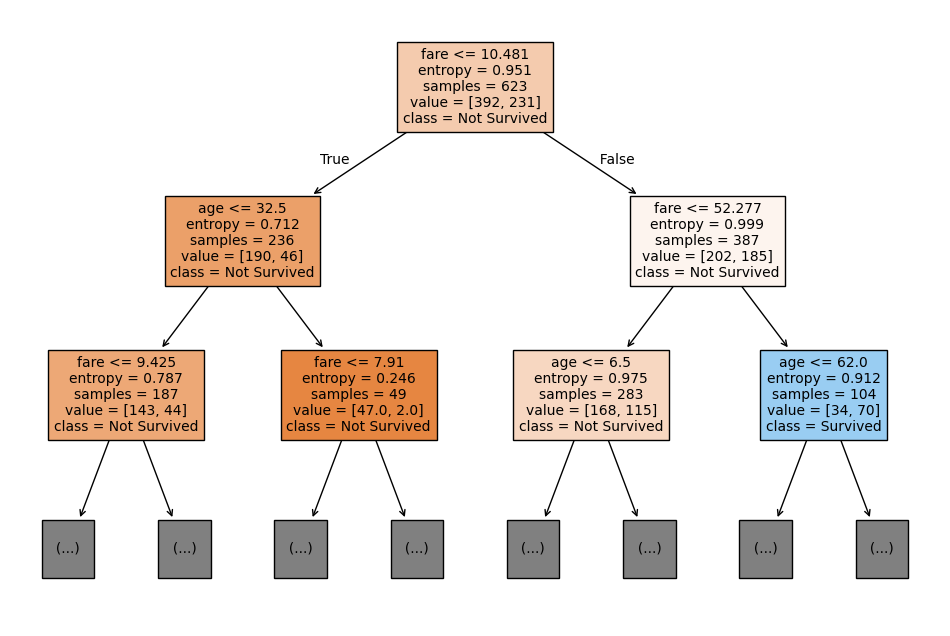

In [ ]:
# Visualize the decision tree
plt.figure(figsize=(12,8))
plot_tree(clf_titanic, feature_names=X_titanic.columns, class_names=['Not Survived', 'Survived'], filled=True, fontsize=10, max_depth=2)
plt.show()

## **Step 8: Classify a New Sample (Titanic Dataset)**

We’ll classify a new Titanic passenger with the following values:

 - Pclass = 1
 - Sex = 0 (male)
 - Age = 30
 - Fare = 50

In [ ]:
new_sample_titanic = np.array([[1, 0, 30, 50]])

# Predict survival for new passenger
prediction_titanic = clf_titanic.predict(new_sample_titanic)
print("Titanic Prediction:", "Survived" if prediction_titanic[0] == 1 else "Not Survived")

Titanic Prediction: Not Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# **Dataset 2: Pima Indians Diabetes Dataset**

## **Step 1: Load Pima Indians Diabetes Dataset**

In [ ]:
# Load Pima Indians Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
diabetes = pd.read_csv(url, names=column_names)

# Check first few rows
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## **Step 2: Preprocess Pima Indians Diabetes Dataset**

In [ ]:
# Define features and target
X_diabetes = diabetes.drop('Outcome', axis=1)
y_diabetes = diabetes['Outcome']

# Normalize the data (StandardScaler)
scaler = StandardScaler()
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

# Check the scaled data
pd.DataFrame(X_diabetes_scaled, columns=X_diabetes.columns).head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


## **Step 3: Train-Test Split for Pima Indians Diabetes Dataset**

In [ ]:
# Train-test split for Pima Indians Diabetes dataset
X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes_scaled, y_diabetes, test_size=0.3, random_state=42
)

## **Step 4: Train ID3 Decision Tree (Pima Indians Diabetes Dataset)**

In [ ]:
# Train ID3 decision tree using entropy
clf_diabetes = DecisionTreeClassifier(criterion='entropy', max_depth=4)
clf_diabetes.fit(X_train_diabetes, y_train_diabetes)

DecisionTreeClassifier(criterion='entropy', max_depth=4)

## **Step 5: Evaluate the Model (Pima Indians Diabetes Dataset)**

In [ ]:
y_pred_diabetes = clf_diabetes.predict(X_test_diabetes)
accuracy_diabetes = metrics.accuracy_score(y_test_diabetes, y_pred_diabetes)
print("Pima Indians Diabetes Accuracy:", accuracy_diabetes)

Pima Indians Diabetes Accuracy: 0.7229437229437229


## **Step 6: Visualize Decision Tree (Pima Indians Diabetes Dataset)**

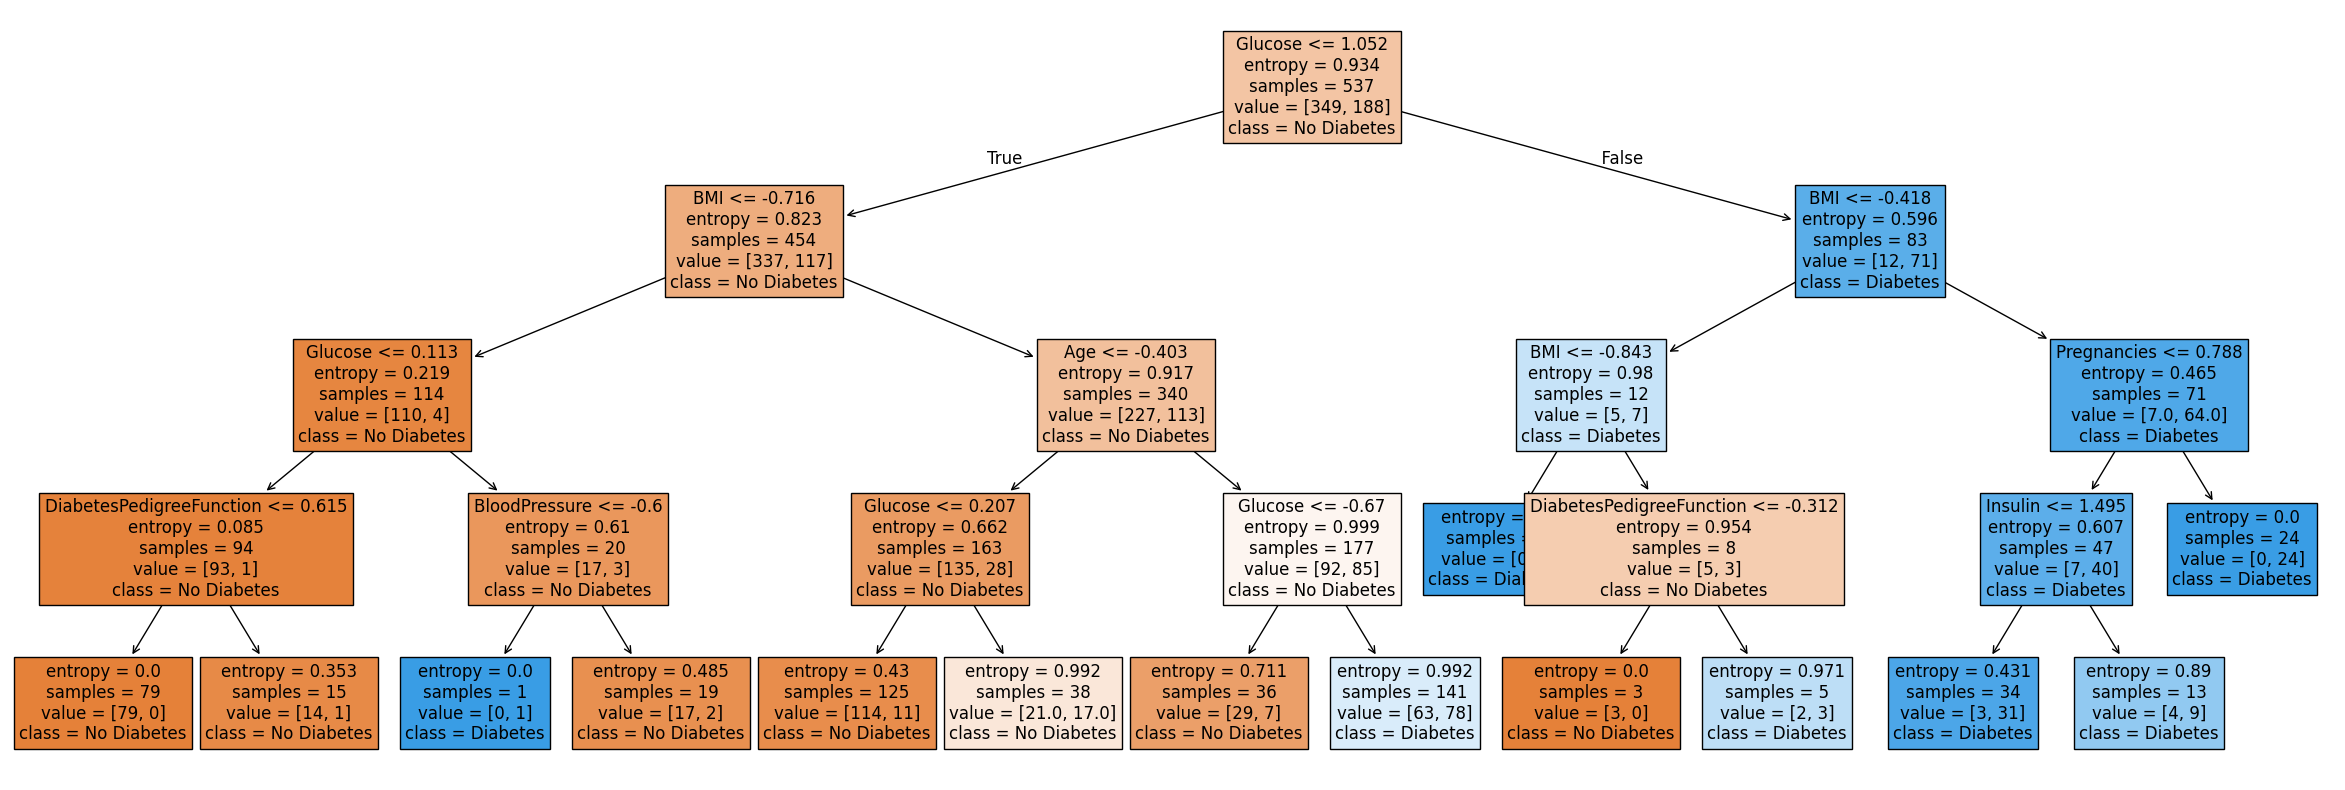

In [ ]:
# Visualize the decision tree with larger text and adjusted figure size
plt.figure(figsize=(30, 10))  # Adjust figure size for better fit
plot_tree(clf_diabetes,
          feature_names=X_diabetes.columns,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          #max_depth=1,  # Limit tree depth
          fontsize=12)  # Increase font size for better readability
plt.show()

## **Step 7: Classify a New Sample (Pima Indians Diabetes Dataset)**

We’ll classify a new Pima Diabetes sample with the following values:

 - Pregnancies = 2
 - Glucose = 150
 - BloodPressure = 80
 - SkinThickness = 30
 - Insulin = 130
 - BMI = 32
 - DiabetesPedigreeFunction = 0.5
 - Age = 40

In [ ]:
new_sample_diabetes = np.array([[2, 150, 80, 30, 130, 32, 0.5, 40]])

# Predict diabetes outcome for new sample
prediction_diabetes = clf_diabetes.predict(new_sample_diabetes)
print("Pima Diabetes Prediction:", "Has Diabetes" if prediction_diabetes[0] == 1 else "No Diabetes")

Pima Diabetes Prediction: Has Diabetes
